In [58]:
from spisea import synthetic, atmospheres, reddening, evolution
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import os
import copy
import pandas as pd
from tqdm import tqdm
import ext_utils
import pdb

In [2]:
%load_ext autoreload
%autoreload 2

# Set up the ExtinctionCoefficientFitter

In [87]:
roman_filters = ['roman,wfi,f062','roman,wfi,f087','roman,wfi,f106','roman,wfi,f129',
             'roman,wfi,f158','roman,wfi,f184','roman,wfi,f213','roman,wfi,f146']
ecf=0
ecf = ext_utils.ExtinctionCoefficientFitter(color_filter_list=roman_filters[:-1],
                                            ext_only_filter_list = roman_filters[-1:])

For roman,wfi,f062, m_ab - m_vega = 0.1418860315199808
For roman,wfi,f087, m_ab - m_vega = 0.5069624249565408
For roman,wfi,f106, m_ab - m_vega = 0.6659690376827427
For roman,wfi,f129, m_ab - m_vega = 0.9739263057526699
For roman,wfi,f158, m_ab - m_vega = 1.3088682252670338
For roman,wfi,f184, m_ab - m_vega = 1.5764881750217157
For roman,wfi,f213, m_ab - m_vega = 1.8314297601129965
For roman,wfi,f146, m_ab - m_vega = 0.9703680920347395
Load or generate extinction + colors grid
Found saved file ./grids/ext_grid_met_0.00_AKs_5.00.h5


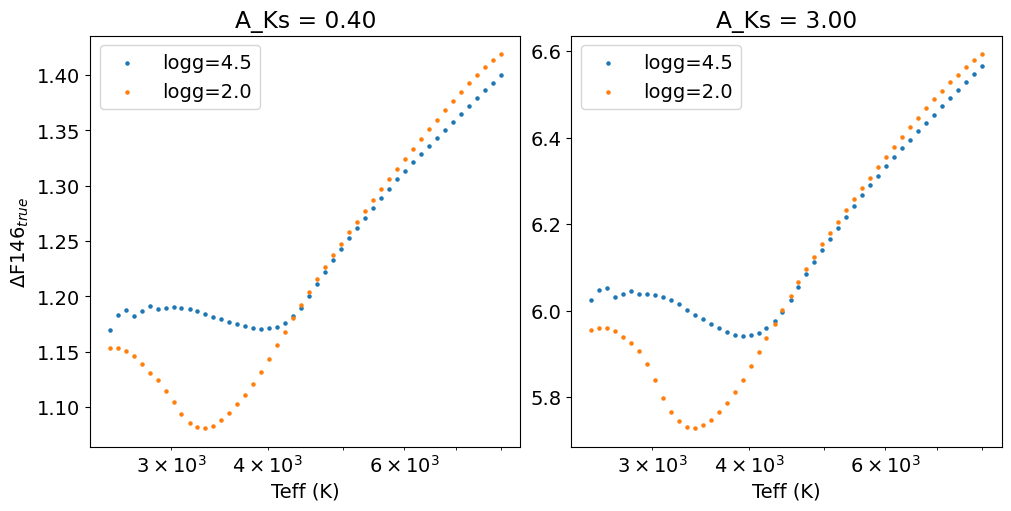

In [89]:
fig,ax = ecf.plot_true_extinction('f146', [0.4,3.0])

# Run a fit and plot the fit quality

In [102]:
ecf.run_fit('f087', ['f062_f087_abs', 'f087_f106_abs'], order=4)

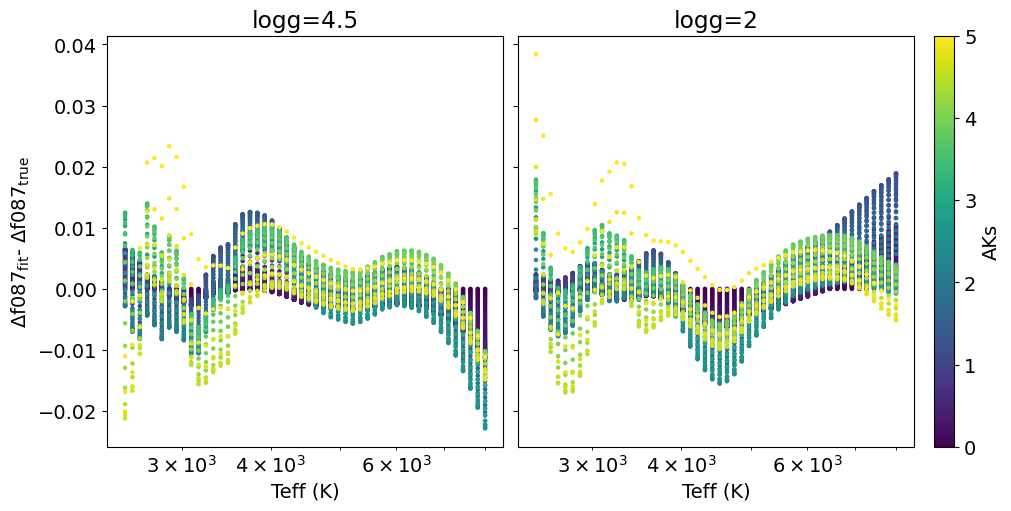

In [104]:
fig,ax = ecf.plot_fit_result()

In [107]:
ecf.best_fit_coeffs

array([ 8.16367270e+00, -9.19147548e-01,  2.58307397e-01, -3.89876585e-02,
        2.35277999e-03,  1.44530236e-01, -4.85801819e-03, -8.68085971e-03,
        1.18238068e-03, -1.47129141e-01,  2.53673401e-02, -1.67694503e-03,
        3.39920383e-02, -1.99290254e-03, -3.06855685e-03, -7.58539923e-01,
        2.20705132e-01, -2.68972481e-02,  1.09455599e-03,  6.79622246e-01,
       -1.15692225e-01,  8.01142080e-03, -4.97687053e-01,  2.09855479e-02,
        1.56962737e-01])

# Examine the fit performance on example SynthPop catalogs

In [114]:
import synthpop as sp

/Users/mhuston/anaconda3/lib/python3.11/site-packages/pydantic/_internal/_config.py:341: UserWarning: Valid config keys have changed in V2:
* 'keep_untouched' has been renamed to 'ignored_types'
  warnings.warn(message, UserWarning)


In [121]:
# Only re-run the catalog generation if needed
if False:
    mod = sp.SynthPop('huston2025_defaults.synthpop_conf', 
                maglim=["W146", 99,"remove"],
                post_processing_kwargs=[{"name": "ProcessDarkCompactObjects","remove": True},
                                        {"name": "ConvertMistMags","conversions": {"AB": 
                                            ["R062","Z087","Y106","J129","W146","H158","F184"]}}],
                obsmag=False
               )

    mod.init_populations()

    cat_lb,_ = mod.process_location(0.5,-1.4,1e-4)
    cat_gc,_ = mod.process_location(0,0,3e-5)

In [ ]:
# Only re-run the catalog extinction analysis if needed
if True:
    cat_lb = pd.read_csv('outputfiles/default/Huston2025_l0.500_b-1.400.csv')
    cat_lb_ext = ecf.get_catalog_true(cat_lb)
    cat_lb_ext.to_hdf('outputfiles/lb_simtab.h5',key='data', index=False)
    cat_gc = pd.read_csv('outputfiles/default/Huston2025_l0.000_b0.000.csv')
    cat_gc_ext = ecf.get_catalog_true(cat_gc)
    cat_gc_ext.to_hdf('outputfiles/gc_simtab.h5',key='data', index=False)

  0%|                                        | 15/61362 [00:00<32:34, 31.38it/s]

Changing to met=0.50 for met=0.49 T=  2290 logg=5.08


  1%|▎                                      | 540/61362 [00:17<30:55, 32.77it/s]

Changing to met=0.50 for met=0.47 T=  2271 logg=5.10


  2%|▋                                     | 1053/61362 [00:33<31:57, 31.45it/s]

...

  5%|█▊                                    | 2930/61362 [01:32<30:22, 32.06it/s]

Changing to met=0.50 for met=0.45 T=  2294 logg=5.11


  6%|██▎                                   | 3728/61362 [01:57<29:22, 32.70it/s]

Changing to met=0.50 for met=0.45 T=  2300 logg=5.11


  7%|██▌                                   | 4132/61362 [02:09<32:55, 28.96it/s]

In [36]:
cat_ext = pd.read_hdf('outputfiles/lb_simtab.h5')
cat_ext2 = pd.read_hdf('outputfiles/gc_simtab.h5')

In [38]:
cat_ext.loc[:,'ext_f146_fit'] = res_func(cat_ext[['A_Ks', 'f062_f087_abs', 'f087_f106_abs']].to_numpy())

KeyError: "['f062_f087_abs', 'f087_f106_abs'] not in index"

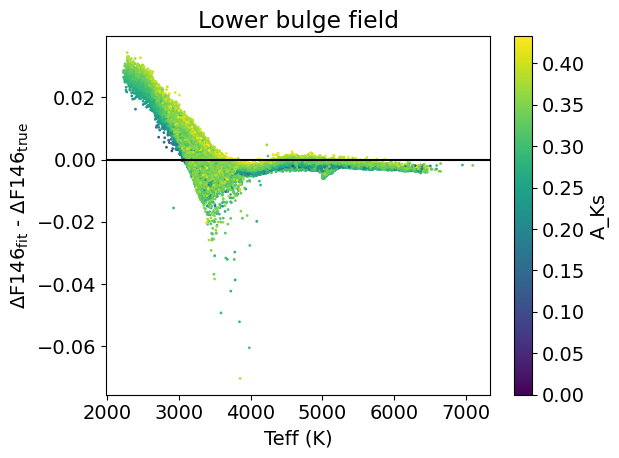

In [63]:
plt.axhline(0, c='k')
plt.scatter(cat_ext['Teff'],cat_ext['delta_f146_fit']-cat_ext['delta_f146_spec'], c=cat_ext['A_Ks'],
           vmin=0,s=1)
plt.colorbar(label='A_Ks')
plt.ylabel(r'$\Delta$F146$_{\rm fit}$ - $\Delta$F146$_{\rm true}$')
plt.xlabel('Teff (K)')
plt.title('Lower bulge field')
plt.tight_layout()
plt.savefig('figures/f146ext_lowerbulge_test.png')

0.9420386814256173


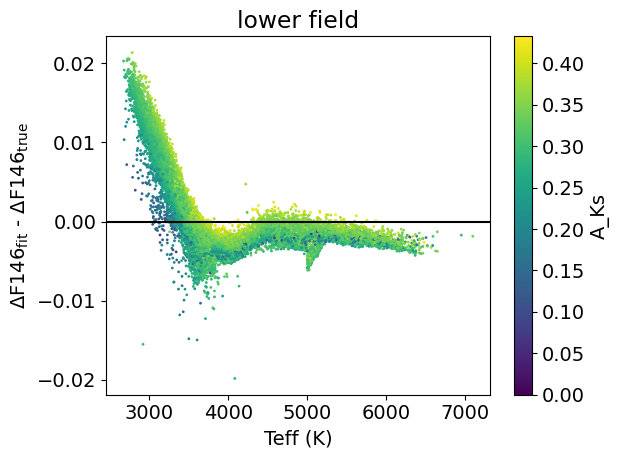

In [64]:
cat_ext_f146 = cat_ext['W146'] + 5*np.log10(100*cat_ext['Dist']) + cat_ext['delta_f146_fit']
keep = cat_ext_f146<=25
diffs = cat_ext['delta_f146_fit'][keep]-cat_ext['delta_f146_spec'][keep]
print(np.sum(np.abs(diffs)<0.01)/len(diffs))
plt.axhline(0, c='k')
plt.scatter(cat_ext['Teff'][keep], diffs, c=cat_ext['A_Ks'][keep], vmin=0,s=1)
plt.colorbar(label='A_Ks')
plt.ylabel(r'$\Delta$F146$_{\rm fit}$ - $\Delta$F146$_{\rm true}$')
plt.xlabel('Teff (K)')
plt.title('lower field')
plt.tight_layout()
plt.savefig('figures/f146ext_lb_test_cut.png')

In [66]:
cat_ext2.loc[:,'delta_f146_fit'] = res_func(cat_ext2[['A_Ks', 'f106_f129_abs', 'f129_f158_abs', 
                                                   'f158_f184_abs']].to_numpy())

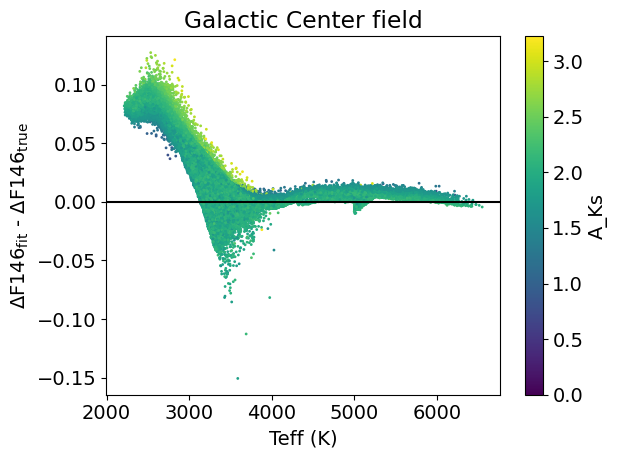

In [67]:
plt.axhline(0, c='k')
plt.scatter(cat_ext2['Teff'],cat_ext2['delta_f146_fit']-cat_ext2['delta_f146_spec'], c=cat_ext2['A_Ks'],
           vmin=0,s=1)
plt.colorbar(label='A_Ks')
plt.ylabel(r'$\Delta$F146$_{\rm fit}$ - $\Delta$F146$_{\rm true}$')
plt.xlabel('Teff (K)')
plt.title('Galactic Center field')
plt.tight_layout()
plt.savefig('figures/f146ext_gc_test.png')

0.9212341893445765


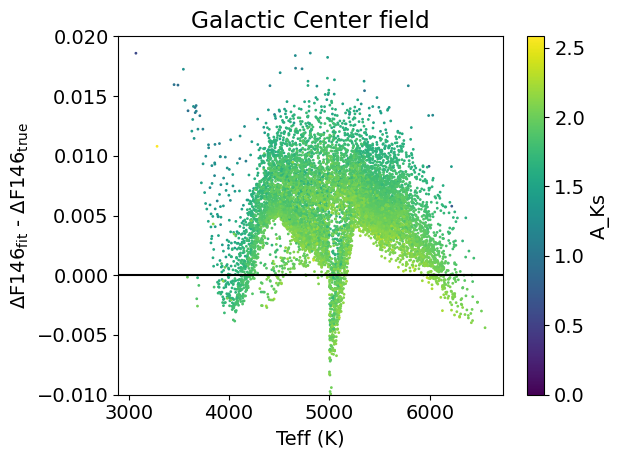

In [68]:
cat_ext2_f146 = cat_ext2['W146'] + 5*np.log10(100*cat_ext2['Dist']) + cat_ext2['delta_f146_fit']
keep = (cat_ext2_f146<=25) & (cat_ext2_f146>15)
diffs = cat_ext2['delta_f146_fit'][keep]-cat_ext2['delta_f146_spec'][keep]
print(np.sum(np.abs(diffs)<0.01)/len(diffs))
plt.axhline(0, c='k')
plt.scatter(cat_ext2['Teff'][keep], cat_ext2['delta_f146_fit'][keep]-cat_ext2['delta_f146_spec'][keep], 
            c=cat_ext2['A_Ks'][keep], vmin=0,s=1)
plt.colorbar(label='A_Ks')
plt.ylabel(r'$\Delta$F146$_{\rm fit}$ - $\Delta$F146$_{\rm true}$')
plt.xlabel('Teff (K)')
plt.title('Galactic Center field')
plt.ylim(-0.01,0.02)
plt.tight_layout()
plt.savefig('figures/f146ext_gc_test_cut.png')

0.9212341893445765


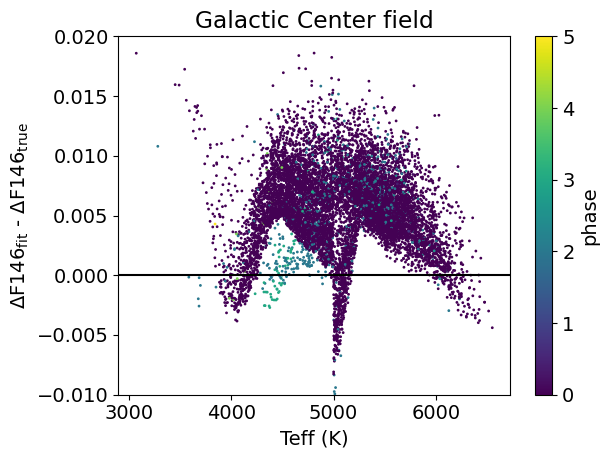

In [69]:
cat_ext2_f146 = cat_ext2['W146'] + 5*np.log10(100*cat_ext2['Dist']) + cat_ext2['delta_f146_fit']
keep = (cat_ext2_f146<=25) & (cat_ext2_f146>15)
diffs = cat_ext2['delta_f146_fit'][keep]-cat_ext2['delta_f146_spec'][keep]
print(np.sum(np.abs(diffs)<0.01)/len(diffs))
plt.axhline(0, c='k')
plt.scatter(cat_ext2['Teff'][keep], cat_ext2['delta_f146_fit'][keep]-cat_ext2['delta_f146_spec'][keep], 
            c=cat_ext2['phase'][keep], vmin=0,s=1)
plt.colorbar(label='phase')
plt.ylabel(r'$\Delta$F146$_{\rm fit}$ - $\Delta$F146$_{\rm true}$')
plt.xlabel('Teff (K)')
plt.title('Galactic Center field')
plt.ylim(-0.01,0.02)
plt.tight_layout()
plt.savefig('figures/f146ext_gc_test_cut_phase.png')

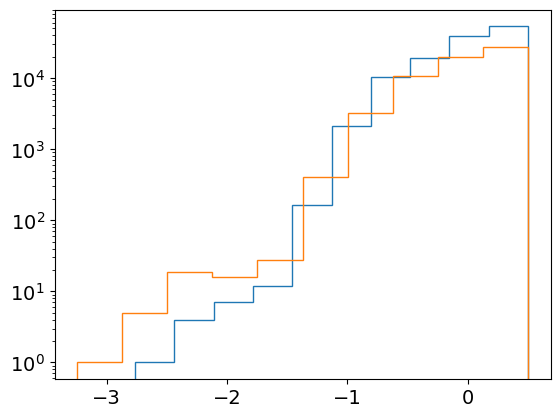

In [70]:
plt.hist(cat_ext2['Fe/H_initial'], histtype='step')
plt.hist(cat_ext['Fe/H_initial'], histtype='step')
plt.yscale('log')

In [74]:
# cat_ext.to_hdf('outputfiles/lb_simtab.h5',key='data', index=False)
# cat_ext2.to_hdf('outputfiles/gc_simtab.h5',key='data', index=False)

In [75]:
np.quantile(cat_ext['Fe/H_initial'], [(1.0-0.68)/2, 0.5, (1.0-0.68)/2+0.68])

array([-0.38496531,  0.07850204,  0.3330378 ])